# Lake Shoreline Analysis Notebook

This notebook:
- discovers lake / shoreline line files
- skips `area_lake` files
- loads and inspects shoreline geometries
- computes shoreline length by map
- computes consecutive-map displacement metrics
- plots shoreline overlay, length trend, and displacement
- saves outputs only if `SAVE_OUTPUTS = True`

In [11]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

TARGET_EPSG = 2056
SAVE_OUTPUTS = True

REPO_ROOT = Path("../..")

DATA_DIR = REPO_ROOT / "stat_analysis" / "data"
if not DATA_DIR.exists():
    DATA_DIR = Path("../stat_analysis/data")

OUTPUT_DIR = REPO_ROOT / "stat_analysis" / "output" / "lake_shoreline_analysis"
if not OUTPUT_DIR.parent.exists():
    OUTPUT_DIR = Path("../stat_analysis/output/lake_shoreline_analysis")

TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

MAP_ORDER = {
    "melotte": 1721,
    "berney": 1831,
    "renove": 1888,
    "1937": 1937,
    "1959": 1959,
    "contemporain": 2021,
}

MAP_LABELS = {
    "melotte": "Melotte (1721)",
    "berney": "Berney (1831)",
    "renove": "Rénové (1888)",
    "1937": "1937",
    "1959": "1959",
    "contemporain": "Contemporary (2021)",
}

LAKE_COLORS = {
    "melotte": "#000000",
    "berney": "#007AFF",
    "renove": "#34C759",
    "1937": "#FF9F0A",
    "1959": "#FF3B30",
    "contemporain": "#AF52DE",
}

print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

DATA_DIR: ../../stat_analysis/data True
OUTPUT_DIR: ../../stat_analysis/output/lake_shoreline_analysis
SAVE_OUTPUTS: True


## 1. Helper functions

In [12]:
def normalize_text(value):
    if not isinstance(value, str):
        return ""
    value = value.lower().strip()
    return "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )


def infer_map_key(filename):
    lower = normalize_text(filename)

    for key in MAP_ORDER:
        if key in lower:
            return key

    match = re.search(r"\d{4}", lower)
    return match.group() if match else None


def sort_key_for_map(map_key):
    if map_key in MAP_ORDER:
        return MAP_ORDER[map_key]
    if str(map_key).isdigit():
        return int(map_key)
    return 9999


def label_for_map(map_key):
    return MAP_LABELS.get(map_key, str(map_key))


def maybe_save_table(df, path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
        print("Saved:", path)


def maybe_savefig(path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved:", path)

## 2. Discover shoreline files

In [13]:
def discover_lake_files(data_dir):
    supported = {".gpkg", ".geojson"}
    files = []

    for path in sorted(data_dir.glob("*")):
        if path.suffix.lower() not in supported:
            continue

        lower = normalize_text(path.name)

        # Use regular lake/shoreline files; skip area_lake.
        if "area_lake" in lower:
            continue

        if not any(x in lower for x in ["lake", "lac", "shore"]):
            continue

        map_key = infer_map_key(path.name)
        if not map_key:
            print(f"SKIP no map key: {path.name}")
            continue

        print(f"FOUND lake shoreline file: {map_key} -> {path.name}")
        files.append((map_key, path))

    return sorted(files, key=lambda x: sort_key_for_map(x[0]))


files = discover_lake_files(DATA_DIR)

display(pd.DataFrame([
    {
        "map_key": m,
        "map_label": label_for_map(m),
        "source_file": p.name,
        "path": str(p),
    }
    for m, p in files
]))

FOUND lake shoreline file: 1937 -> 1937_lake.gpkg
FOUND lake shoreline file: 1959 -> 1959_lake.gpkg
FOUND lake shoreline file: berney -> berney_lake.gpkg
FOUND lake shoreline file: contemporain -> contemporain_lake.gpkg
FOUND lake shoreline file: melotte -> melotte_lake.gpkg
FOUND lake shoreline file: renove -> renove_lake.gpkg


,map_key,map_label,source_file,path
0,melotte,Melotte (1721),melotte_lake.gpkg,../../stat_analysis/data/melotte_lake.gpkg
1,berney,Berney (1831),berney_lake.gpkg,../../stat_analysis/data/berney_lake.gpkg
2,renove,Rénové (1888),renove_lake.gpkg,../../stat_analysis/data/renove_lake.gpkg
3,1937,1937,1937_lake.gpkg,../../stat_analysis/data/1937_lake.gpkg
4,1959,1959,1959_lake.gpkg,../../stat_analysis/data/1959_lake.gpkg
5,contemporain,Contemporary (2021),contemporain_lake.gpkg,../../stat_analysis/data/contemporain_lake.gpkg


## 3. Load and inspect shoreline layers

In [14]:
def load_layer(path):
    gdf = gpd.read_file(path)

    if gdf.crs is None:
        raise ValueError(f"Missing CRS in {path}")

    gdf = gdf.to_crs(epsg=TARGET_EPSG)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["geometry"] = gdf.geometry.make_valid()

    return gdf


def load_lake_layers(files):
    layers = {}

    for map_key, path in files:
        gdf = load_layer(path)
        geom = gdf.geometry.union_all()

        if geom.is_empty:
            print(f"WARNING: empty geometry in {path.name}")
            continue

        layers[map_key] = {
            "gdf": gdf,
            "geom": geom,
            "source_file": path.name,
        }

    return layers


layers = load_lake_layers(files)

inventory_rows = []
for map_key, path in files:
    gdf = gpd.read_file(path)
    inventory_rows.append({
        "map_key": map_key,
        "map_label": label_for_map(map_key),
        "source_file": path.name,
        "rows": len(gdf),
        "crs": str(gdf.crs),
        "geometry_types": ", ".join(gdf.geom_type.value_counts().index.astype(str)),
        "columns": ", ".join(gdf.columns.astype(str)),
    })

inventory = pd.DataFrame(inventory_rows)
if not inventory.empty:
    inventory["sort_key"] = inventory["map_key"].apply(sort_key_for_map)
    inventory = inventory.sort_values("sort_key").drop(columns=["sort_key"])

display(inventory)
maybe_save_table(inventory, TABLES_DIR / "lake_layer_inventory.csv")

,map_key,map_label,source_file,rows,crs,geometry_types,columns
0,melotte,Melotte (1721),melotte_lake.gpkg,2,EPSG:2056,MultiLineString,"id, geometry"
1,berney,Berney (1831),berney_lake.gpkg,1,EPSG:2056,MultiLineString,"id, geometry"
2,renove,Rénové (1888),renove_lake.gpkg,1,EPSG:2056,MultiLineString,"id, geometry"
3,1937,1937,1937_lake.gpkg,3,EPSG:21781,MultiLineString,"id, geometry"
4,1959,1959,1959_lake.gpkg,3,EPSG:2056,MultiLineString,"id, name, Name_1, length, geometry"
5,contemporain,Contemporary (2021),contemporain_lake.gpkg,1,EPSG:2056,MultiLineString,"id, length, geometry"


Saved: ../../stat_analysis/output/lake_shoreline_analysis/tables/lake_layer_inventory.csv


## 4. Plot each shoreline layer


Melotte (1721) | melotte_lake.gpkg


,id,geometry
0,11,"MULTILINESTRING ((2535909.962 1151626.835, 2535958.683 1151630.603, 2535990.717 1151633.693, 2536035.597 1151639.222, 2536068.932 1151644.913, 2536092.266 1151655.401, 2536116.983 1151666.296, 2536144.383 1151680.687, 2536181.783 1151704.753, 2536227.151 1151734.348, 2536256.421 1151754.512, 2536270.893 1151763.943, 2536278.373 1151766.707, 2536308.293 1151763.455, 2536340.977 1151757.601, 2536381.142 1151743.454, 2536433.827 1151723.616, 2536479.683 1151704.428, 2536518.059 1151688.33, 2536542.288 1151676.622, 2536570.744 1151665.076, 2536595.136 1151652.393, 2536675.79 1151601.821, 2536708.149 1151585.723, 2536738.069 1151571.088, 2536753.843 1151563.446, 2536780.185 1151554.99, 2536801.162 1151548.811, 2536817.911 1151540.192, 2536847.993 1151522.631, 2536878.076 1151507.833, 2536908.321 1151494.987, 2536954.99 1151460.514, 2536993.366 1151437.749, 2537017.107 1151416.609, 2537042.637 1151393.194, 2537071.419 1151369.453, 2537092.72 1151349.452, 2537135.812 1151308.474, 2537188.497 1151263.757))"
1,12,"MULTILINESTRING ((2537188.497 1151263.757, 2537266.387 1151187.757, 2537491.764 1151048.726, 2537622.014 1150948.477, 2537674.882 1150900.548, 2537691.346 1150886.279, 2537691.346 1150881.523, 2537735.068 1150861.4, 2537756.654 1150850.973, 2537761.319 1150857.467, 2537744.078 1150864.693, 2537731.181 1150870.913, 2537719.336 1150876.675, 2537716.134 1150878.184, 2537713.207 1150878.596, 2537707.902 1150881.797, 2537705.844 1150884.038, 2537705.981 1150886.92, 2537707.628 1150890.029, 2537710.166 1150892.316, 2537714.328 1150890.853, 2537718.146 1150888.383, 2537719.656 1150886.782, 2537719.816 1150885.365, 2537724.526 1150885.502, 2537728.162 1150885.25, 2537729.923 1150884.724, 2537737.469 1150882.049, 2537744.329 1150879.351, 2537752.79 1150876.195, 2537759.147 1150874, 2537761.571 1150876.972, 2537764.772 1150878.71, 2537768.842 1150878.665, 2537770.306 1150876.972, 2537770.992 1150874.32, 2537770.9 1150870.89, 2537769.528 1150867.323, 2537774.285 1150872.856, 2537782.563 1150882.964, 2537795.46 1150886.714, 2537813.707 1150893.116, 2537827.702 1150898.787, 2537849.288 1150907.02, 2537861.545 1150909.764, 2537873.619 1150922.386, 2537936.823 1150955.955, 2537941.213 1150964.736, 2537940.116 1150971.321, 2537960.605 1150983.029, 2538007.436 1150984.493, 2538059.756 1150989.615, 2538090.184 1150991.414, 2538113.234 1150990.682, 2538197.018 1150966.779, 2538253.118 1150940.436, 2538290.193 1150924.337, 2538335.561 1150902.385, 2538380.929 1150882.872, 2538435.078 1150869.945, 2538469.226 1150860.432, 2538508.496 1150848.846, 2538550.572 1150833.479, 2538625.453 1150806.039, 2538658.26 1150791.892, 2538714.238 1150768.111, 2538747.898 1150755.671, 2538773.997 1150752.256, 2538784.607 1150752.866, 2538796.193 1150751.646, 2538807.657 1150744.085, 2538828.634 1150736.524))"


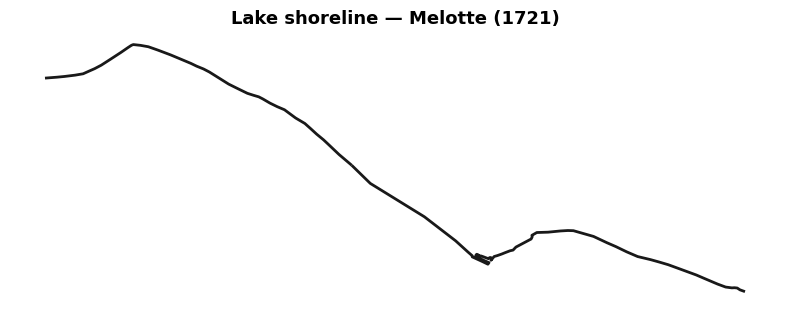


Berney (1831) | berney_lake.gpkg


,id,geometry
0,1,"MULTILINESTRING ((2535901.445 1151605.094, 2535914.415 1151606.862, 2535946.28 1151595.999, 2535972.352 1151593.827, 2535989.733 1151598.896, 2536021.599 1151602.517, 2536063.603 1151601.793, 2536096.193 1151610.665, 2536107.056 1151617.907, 2536113.937 1151618.631, 2536142.543 1151628.77, 2536150.509 1151633.839, 2536172.598 1151645.065, 2536210.438 1151666.067, 2536226.009 1151676.93, 2536233.794 1151685.259, 2536237.687 1151691.777, 2536243.662 1151693.949, 2536244.205 1151693.949, 2536281.502 1151715.495, 2536313.911 1151731.971, 2536356.82 1151752.249, 2536374.926 1151754.421, 2536390.859 1151755.146, 2536414.396 1151748.628, 2536478.489 1151725.091, 2536512.165 1151705.537, 2536542.039 1151684.535, 2536569.378 1151663.17, 2536592.372 1151641.806, 2536602.873 1151637.461, 2536609.391 1151637.098, 2536620.435 1151645.246, 2536629.488 1151646.151, 2536639.808 1151641.444, 2536656.465 1151630.943, 2536697.745 1151592.559, 2536709.333 1151584.593, 2536723.093 1151583.869, 2536729.611 1151587.128, 2536740.836 1151587.128, 2536773.788 1151574.454, 2536839.692 1151540.416, 2536859.607 1151524.483, 2536873.73 1151517.965, 2536882.058 1151517.965, 2536886.041 1151520.862, 2536894.37 1151520.5, 2536905.233 1151515.43, 2536944.703 1151485.737, 2536972.947 1151454.596, 2536989.604 1151440.112, 2537011.331 1151414.04, 2537019.659 1151401.366, 2537031.971 1151391.227, 2537039.753 1151394.411), (2537039.753 1151394.411, 2537039.937 1151394.486, 2537039.575 1151394.486, 2537039.753 1151394.411), (2537039.753 1151394.411, 2537048.99 1151390.503, 2537068.725 1151374.208, 2537096.245 1151344.153, 2537107.832 1151330.393, 2537125.938 1151306.494, 2537136.077 1151297.441, 2537164.683 1151264.127, 2537176.995 1151258.333, 2537187.134 1151245.298, 2537222.621 1151219.226, 2537243.623 1151196.775, 2537298.663 1151154.771, 2537371.085 1151125.078, 2537437.713 1151099.006, 2537512.307 1151056.277, 2537544.173 1151031.654, 2537560.83 1151013.548, 2537576.038 1150992.908, 2537601.386 1150953.801, 2537606.455 1150947.283, 2537623.112 1150929.539, 2537653.529 1150904.192, 2537663.306 1150893.329, 2537665.117 1150880.836, 2537670.91 1150872.145, 2537676.885 1150870.516, 2537682.498 1150870.878, 2537689.378 1150873.413, 2537731.383 1150863.998, 2537751.661 1150874.137, 2537758.541 1150891.156, 2537778.819 1150915.055, 2537799.097 1150932.436, 2537823.72 1150944.024, 2537841.101 1150943.299, 2537851.24 1150940.403, 2537862.104 1150930.264, 2537929.093 1150958.146, 2537934.887 1150956.697, 2537999.705 1150981.683, 2538006.947 1150983.856, 2538028.311 1150993.632, 2538048.951 1150999.426, 2538060.539 1151001.237, 2538098.56 1151010.652, 2538151.066 1151012.1, 2538188.363 1151007.03, 2538230.005 1150998.34, 2538248.835 1150993.995, 2538274.182 1150982.407, 2538274.907 1150982.407, 2538289.391 1150978.062, 2538303.875 1150967.923, 2538324.153 1150959.956, 2538350.949 1150948.369, 2538383.539 1150933.16, 2538399.472 1150927.367, 2538410.335 1150924.47, 2538429.889 1150917.952, 2538460.306 1150907.089, 2538506.656 1150886.811, 2538529.831 1150878.12, 2538571.835 1150862.187, 2538613.116 1150844.806, 2538641.36 1150827.425, 2538710.885 1150779.627, 2538743.474 1150767.315, 2538773.892 1150765.142, 2538797.791 1150769.488, 2538827.483 1150778.178, 2538839.071 1150764.418, 2538843.416 1150758.624, 2538861.522 1150755.728, 2538904.975 1150755.003, 2538945.531 1150748.485, 2538976.454 1150737.958))"


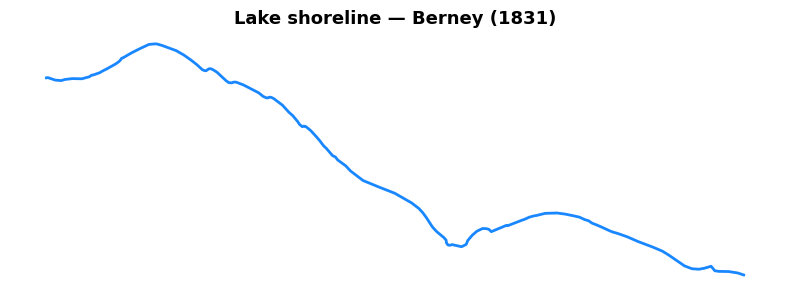


Rénové (1888) | renove_lake.gpkg


,id,geometry
0,1,"MULTILINESTRING ((2538929.024 1150622.329, 2538883.661 1150665.947, 2538825.684 1150713.054, 2538797.602 1150740.23, 2538773.143 1150760.16, 2538749.59 1150772.842, 2538720.601 1150767.407, 2538659.001 1150800.019, 2538476.011 1150888.796, 2538429.811 1150893.326, 2538401.728 1150912.349, 2538362.775 1150917.785, 2538344.657 1150926.843, 2538320.198 1150944.055, 2538275.81 1150967.608, 2538267.657 1150965.797, 2538176.162 1150995.691, 2538159.856 1150992.067, 2538081.044 1150999.315, 2538004.949 1150973.044, 2538027.596 1150910.537, 2538032.126 1150907.82, 2538028.502 1150903.29, 2538021.255 1150903.29, 2538023.067 1150908.726, 2538002.231 1150972.138, 2537868.16 1150928.655, 2537865.442 1150935.902, 2537785.724 1150907.82, 2537791.159 1150897.855, 2537784.818 1150897.855, 2537767.606 1150850.749, 2537799.312 1150781.901, 2537849.136 1150759.254, 2537851.854 1150763.783, 2537855.477 1150754.724, 2537852.759 1150746.571, 2537845.512 1150749.289, 2537794.783 1150769.219, 2537790.253 1150734.795, 2537432.427 1151055.48, 2537446.921 1151106.209, 2537332.779 1151152.41, 2537290.202 1151177.775, 2537184.213 1151267.458, 2537182.401 1151267.458, 2537178.778 1151269.27, 2537184.213 1151277.423, 2537189.649 1151274.705, 2537187.837 1151278.328, 2537185.119 1151281.952, 2537176.966 1151276.517, 2537076.412 1151381.6, 2537055.577 1151394.282, 2537032.93 1151401.529, 2536912.446 1151507.518, 2536906.105 1151514.766, 2536768.41 1151580.895, 2536724.021 1151593.578, 2536714.057 1151591.766, 2536703.186 1151585.425, 2536682.351 1151594.484, 2536633.433 1151634.343, 2536618.938 1151634.343, 2536606.256 1151633.437, 2536577.267 1151644.308, 2536504.796 1151694.132, 2536486.679 1151705.908, 2536459.502 1151721.308, 2536408.772 1151735.802, 2536359.854 1151744.861, 2536348.077 1151741.238, 2536340.83 1151727.649, 2536329.054 1151720.402, 2536287.383 1151712.249, 2536248.43 1151692.32, 2536224.877 1151673.296, 2536185.017 1151642.496, 2536151.952 1151616.225, 2536129.305 1151603.543, 2536021.957 1151572.742, 2536004.293 1151571.837, 2535965.792 1151565.495, 2535892.255 1151581.638))"


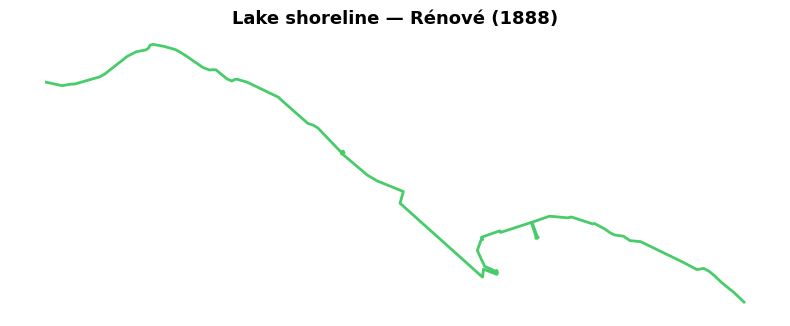


1937 | 1937_lake.gpkg


,id,geometry
0,0,"MULTILINESTRING ((2535880.574 1151550.365, 2535909.94 1151559.811, 2535923.866 1151560.772, 2535953.399 1151554.289, 2535994.458 1151539.402, 2535998.78 1151556.209, 2536001.301 1151563.773, 2536011.626 1151576.259, 2536020.27 1151586.223, 2536022.311 1151584.422, 2536026.993 1151587.304, 2536025.432 1151590.905, 2536039.598 1151600.75, 2536055.446 1151608.673, 2536069.132 1151614.196, 2536080.297 1151617.317, 2536140.204 1151607.713, 2536140.324 1151613.835, 2536140.324 1151619.958, 2536139.844 1151624.88, 2536149.568 1151630.763, 2536150.589 1151643.249, 2536153.23 1151649.432, 2536159.713 1151656.395, 2536160.613 1151664.198, 2536168.177 1151668.28, 2536182.523 1151674.463, 2536186.185 1151675.003, 2536190.867 1151671.041, 2536191.047 1151682.446, 2536191.587 1151689.53, 2536194.889 1151694.872, 2536200.591 1151698.114, 2536205.754 1151700.995, 2536215.898 1151709.219, 2536225.622 1151717.682, 2536237.088 1151722.004, 2536247.833 1151724.886, 2536264.64 1151728.307, 2536283.008 1151729.748, 2536308.94 1151729.028, 2536334.031 1151726.386, 2536337.633 1151729.508, 2536349.999 1151731.068, 2536361.524 1151726.747))"
1,0,"MULTILINESTRING ((2536361.526 1151726.744, 2536462.06 1151679.263, 2536476.085 1151671.361, 2536482.801 1151669.386, 2536515.198 1151649.04, 2536562.014 1151617.829, 2536567.545 1151614.47, 2536571.101 1151606.174, 2536574.459 1151603.803, 2536581.175 1151614.075, 2536587.299 1151616.841, 2536601.127 1151620.594, 2536607.053 1151623.162, 2536637.474 1151607.557, 2536690.019 1151571.407, 2536666.808 1151514.121, 2536699.105 1151500.195, 2536705.92 1151483.503, 2536720.637 1151476.49, 2536724.983 1151485.379, 2536734.563 1151509.183, 2536782.664 1151485.182, 2536814.27 1151459.897, 2536840.74 1151431.847, 2536862.074 1151405.772, 2536865.63 1151399.055, 2536874.914 1151392.932, 2536886.371 1151391.549, 2536896.248 1151396.883, 2536907.903 1151408.537, 2536931.706 1151433.328, 2536939.509 1151432.341, 2536946.028 1151437.477, 2536974.078 1151411.105, 2537018.722 1151369.622, 2537098.033 1151298.114, 2537125.491 1151270.261, 2537132.405 1151258.606, 2537132.207 1151248.137, 2537132.602 1151231.938, 2537138.923 1151203.493, 2537146.232 1151185.912, 2537147.417 1151174.455, 2537145.047 1151169.912, 2537132.602 1151157.072, 2537119.96 1151144.627, 2537108.503 1151125.466, 2537134.182 1151111.44, 2537159.072 1151099.193, 2537167.961 1151094.057, 2537182.184 1151090.106, 2537225.84 1151059.29, 2537236.705 1151043.882, 2537240.705 1151043.833, 2537242.779 1151041.413, 2537249.396 1151048.821, 2537272.953 1151028.326, 2537282.78 1151025.215, 2537292.657 1151023.734, 2537316.954 1151022.746, 2537334.239 1151025.314, 2537343.326 1151027.684, 2537352.215 1151033.117, 2537358.536 1151028.376, 2537366.042 1151039.191, 2537372.462 1151048.278, 2537374.339 1151046.796, 2537375.821 1151042.45, 2537386.29 1151037.907, 2537404.661 1151023.684, 2537418.785 1151012.721, 2537454.243 1150983.14, 2537452.465 1150981.362, 2537465.108 1150969.707, 2537486.738 1150994.152, 2537489.405 1150996.671, 2537522.344 1150966.003, 2537520.566 1150962.694, 2537521.406 1150957.805, 2537524.468 1150953.558, 2537531.727 1150952.571, 2537617.014 1150874.839, 2537686.004 1150812.319, 2537784.724 1150721.797, 2537786.847 1150720.908, 2537828.627 1150738.637, 2537851.344 1150747.724, 2537849.072 1150750.687, 2537826.849 1150760.169, 2537812.626 1150774.885, 2537794.551 1150792.762, 2537787.835 1150800.565, 2537784.675 1150807.775, 2537787.588 1150811.529, 2537776.23 1150839.233, 2537769.711 1150854.197, 2537784.181 1150889.951, 2537787.588 1150891.482, 2537784.576 1150900.569, 2537814.058 1150911.532, 2537868.579 1150931.878, 2537873.517 1150920.718, 2537881.246 1150923.162, 2537900.111 1150912.791, 2537899.716 1150909.236, 2537899.716 1150905.581, 2537901.79 1150902.816, 2537904.16 1150901.63, 2537907.025 1150901.63, 2537909.938 1150902.668, 2537913.049 1150908.248, 2537914.729 1150910.767, 2537923.42 1150913.68, 2538020.016 1150947.85

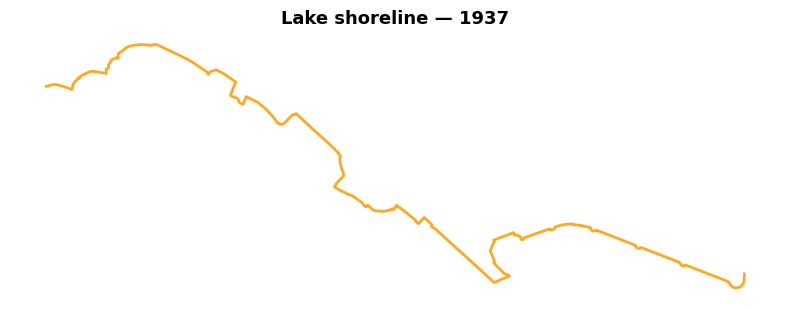


1959 | 1959_lake.gpkg


,id,name,Name_1,length,geometry
0,NaN,lake side,None,1383.603559,"MULTILINESTRING ((2538960.729 1150699.624, 2538848.431 1150716.85, 2538809.3 1150699.043, 2538778.816 1150717.914, 2538558.171 1150812.269, 2538221.398 1150944.365, 2538144.462 1150970.494, 2538071.882 1150966.14, 2538016.72 1150948.72))"
1,NaN,lake side,None,2171.345509,"MULTILINESTRING ((2538016.72 1150948.72, 2537909.301 1150909.527, 2537861.398 1150926.946, 2537787.366 1150899.366, 2537764.14 1150852.914, 2537793.172 1150796.301, 2537865.753 1150739.688, 2537783.011 1150723.721, 2537489.786 1150996.623, 2537463.657 1150974.849, 2537372.205 1151050.333, 2537337.367 1151024.204, 2537267.689 1151030.011, 2537109.464 1151125.817, 2537144.302 1151175.172, 2537125.431 1151276.784, 2536948.335 1151439.365, 2536888.819 1151395.816, 2536867.045 1151400.171, 2536859.787 1151423.397, 2536790.109 1151484.365, 2536739.303 1151511.945, 2536723.335 1151480.01, 2536668.174 1151527.913))"
2,NaN,lake side,None,1080.992212,"MULTILINESTRING ((2536668.174 1151527.913, 2536687.045 1151578.719, 2536611.561 1151629.526, 2536576.722 1151612.106, 2536476.561 1151678.881, 2536350.271 1151739.848, 2536241.4 1151732.59, 2536186.239 1151697.752, 2536136.884 1151616.461, 2536080.272 1151622.268, 2536032.368 1151607.752, 2536001.885 1151568.558, 2535997.53 1151548.236, 2535935.11 1151567.107, 2535883.361 1151558.936))"


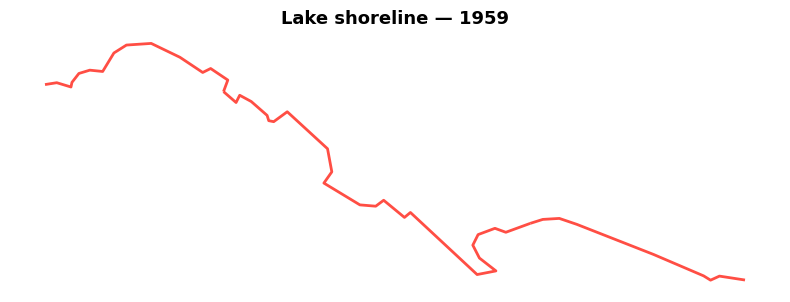


Contemporary (2021) | contemporain_lake.gpkg


id       length  \
0 NaN  9271.709734   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

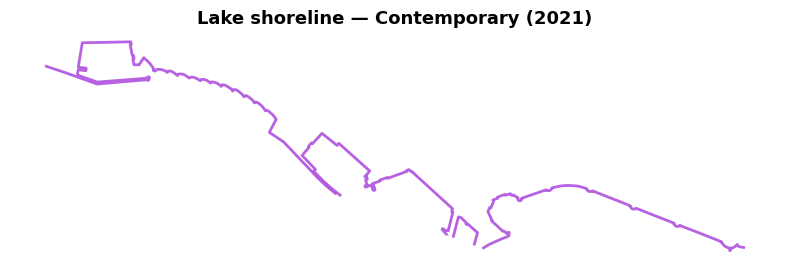

In [15]:
def plot_single_shoreline(map_key, layer):
    fig, ax = plt.subplots(figsize=(8, 8))

    layer["gdf"].plot(
        ax=ax,
        color=LAKE_COLORS.get(map_key, "#8E8E93"),
        linewidth=2,
        alpha=0.9,
    )

    ax.set_title(f"Lake shoreline — {label_for_map(map_key)}", fontsize=13, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()


for map_key in sorted(layers.keys(), key=sort_key_for_map):
    print("\n" + "=" * 80)
    print(label_for_map(map_key), "|", layers[map_key]["source_file"])
    display(layers[map_key]["gdf"].head())
    plot_single_shoreline(map_key, layers[map_key])

## 5. Shoreline length table

In [16]:
def build_shoreline_lengths(layers):
    rows = []

    for map_key in sorted(layers.keys(), key=sort_key_for_map):
        geom = layers[map_key]["geom"]
        rows.append({
            "map_key": map_key,
            "map_label": label_for_map(map_key),
            "source_file": layers[map_key]["source_file"],
            "shoreline_length_m": geom.length,
        })

    return pd.DataFrame(rows)


lengths = build_shoreline_lengths(layers)
display(lengths)

maybe_save_table(lengths, TABLES_DIR / "lake_shoreline_lengths.csv")

,map_key,map_label,source_file,shoreline_length_m
0,melotte,Melotte (1721),melotte_lake.gpkg,3472.007897
1,berney,Berney (1831),berney_lake.gpkg,3580.045421
2,renove,Rénové (1888),renove_lake.gpkg,4125.923336
3,1937,1937,1937_lake.gpkg,4247.293038
4,1959,1959,1959_lake.gpkg,4186.608947
5,contemporain,Contemporary (2021),contemporain_lake.gpkg,5927.845545


Saved: ../../stat_analysis/output/lake_shoreline_analysis/tables/lake_shoreline_lengths.csv


## 6. Consecutive-map displacement table

In [17]:
def build_displacement_table(layers):
    rows = []
    ordered = sorted(layers.keys(), key=sort_key_for_map)

    for a, b in zip(ordered[:-1], ordered[1:]):
        geom_a = layers[a]["geom"]
        geom_b = layers[b]["geom"]

        rows.append({
            "period": f"{label_for_map(a)} → {label_for_map(b)}",
            "map_start": a,
            "map_end": b,
            "max_displacement_m": geom_a.hausdorff_distance(geom_b),
            "length_start_m": geom_a.length,
            "length_end_m": geom_b.length,
            "delta_length_m": geom_b.length - geom_a.length,
        })

    return pd.DataFrame(rows)


displacement = build_displacement_table(layers)
display(displacement)

maybe_save_table(displacement, TABLES_DIR / "lake_shoreline_displacement.csv")

,period,map_start,map_end,max_displacement_m,length_start_m,length_end_m,delta_length_m
0,Melotte (1721) → Berney (1831),melotte,berney,147.827107,3472.007897,3580.045421,108.037524
1,Berney (1831) → Rénové (1888),berney,renove,162.769517,3580.045421,4125.923336,545.877916
2,Rénové (1888) → 1937,renove,1937,157.299641,4125.923336,4247.293038,121.369701
3,1937 → 1959,1937,1959,117.216598,4247.293038,4186.608947,-60.684091
4,1959 → Contemporary (2021),1959,contemporain,254.756952,4186.608947,5927.845545,1741.236598


Saved: ../../stat_analysis/output/lake_shoreline_analysis/tables/lake_shoreline_displacement.csv


## 7. Shoreline overlay plot

Saved: ../../stat_analysis/output/lake_shoreline_analysis/figures/lake_shoreline_overlay.png


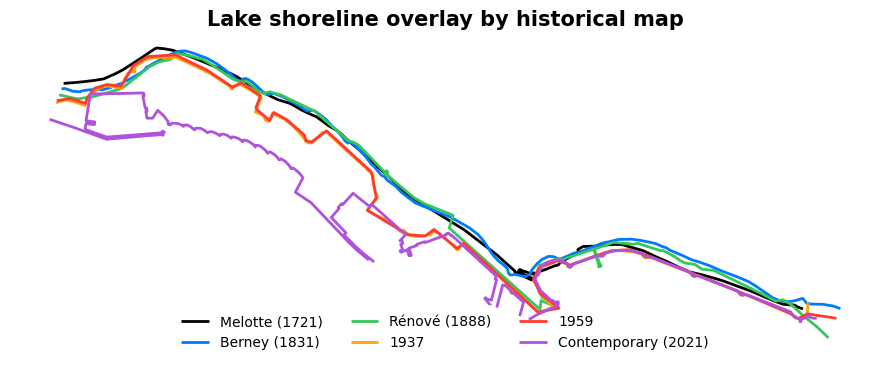

In [18]:
def plot_shoreline_overlay(layers, out_path=None):
    if not layers:
        print("No shoreline layers to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 8))

    for map_key in sorted(layers.keys(), key=sort_key_for_map):
        geom = layers[map_key]["geom"]

        gpd.GeoSeries([geom], crs=f"EPSG:{TARGET_EPSG}").plot(
            ax=ax,
            linewidth=2.0,
            color=LAKE_COLORS.get(map_key, "#8E8E93"),
            label=label_for_map(map_key),
        )

    ax.set_title("Lake shoreline overlay by historical map", fontsize=15, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=3,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    if out_path is not None:
        maybe_savefig(out_path)

    plt.show()


plot_shoreline_overlay(layers, FIGURES_DIR / "lake_shoreline_overlay.png")

## 8. Shoreline length over time

Saved: ../../stat_analysis/output/lake_shoreline_analysis/figures/lake_shoreline_length_over_time.png


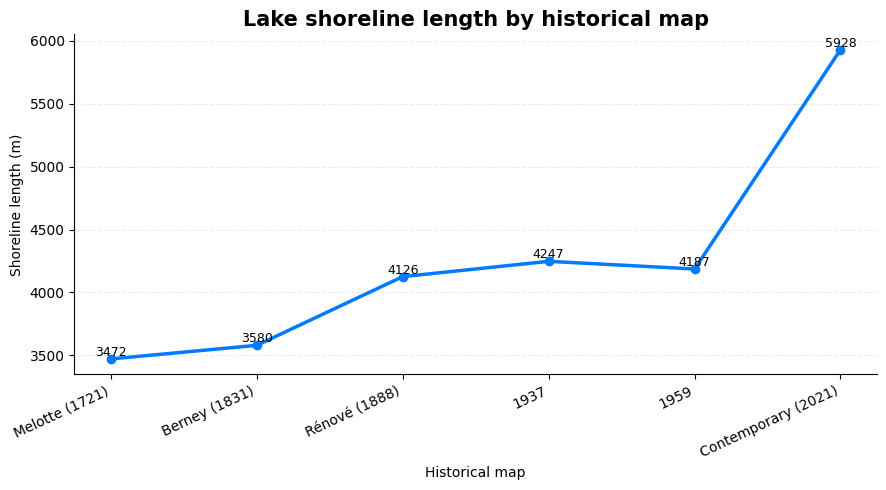

In [19]:
def plot_shoreline_lengths(lengths, out_path=None):
    if lengths.empty:
        print("No shoreline length data to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        lengths["map_label"],
        lengths["shoreline_length_m"],
        marker="o",
        linewidth=2.5,
        color="#007AFF",
    )

    ax.set_title("Lake shoreline length by historical map", fontsize=15, fontweight="bold")
    ax.set_xlabel("Historical map")
    ax.set_ylabel("Shoreline length (m)")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for x, y in zip(lengths["map_label"], lengths["shoreline_length_m"]):
        ax.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=9)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    if out_path is not None:
        maybe_savefig(out_path)

    plt.show()


plot_shoreline_lengths(lengths, FIGURES_DIR / "lake_shoreline_length_over_time.png")

## 9. Shoreline displacement plot

Saved: ../../stat_analysis/output/lake_shoreline_analysis/figures/lake_shoreline_displacement.png


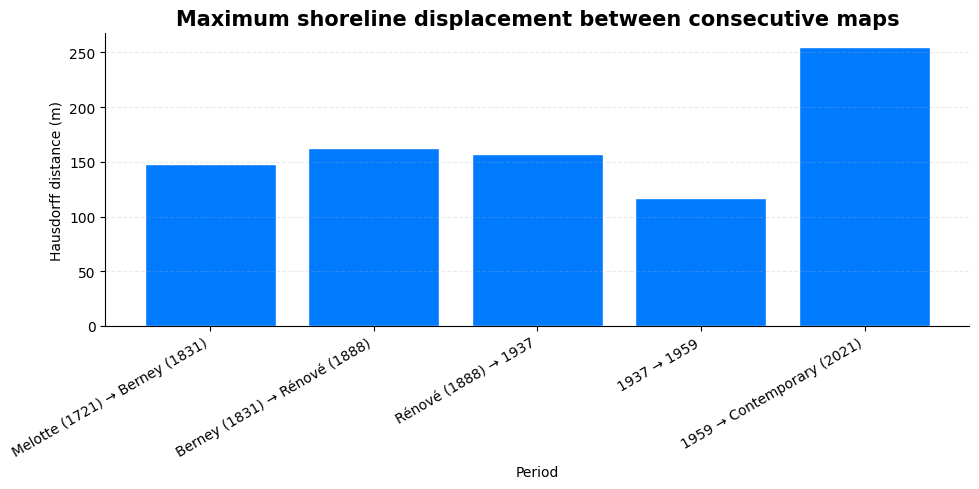

In [20]:
def plot_displacement(displacement, out_path=None):
    if displacement.empty:
        print("No displacement data to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        displacement["period"],
        displacement["max_displacement_m"],
        color="#007AFF",
        edgecolor="white",
        linewidth=1,
    )

    ax.set_title("Maximum shoreline displacement between consecutive maps", fontsize=15, fontweight="bold")
    ax.set_xlabel("Period")
    ax.set_ylabel("Hausdorff distance (m)")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    if out_path is not None:
        maybe_savefig(out_path)

    plt.show()


plot_displacement(displacement, FIGURES_DIR / "lake_shoreline_displacement.png")

## 10. Save outputs

Set:

```python
SAVE_OUTPUTS = True
```

near the top, then rerun the notebook.

Tables and figures will be saved under:

```text
stat_analysis/output/lake_shoreline_analysis/
```